In [1]:
# Import libraries and utilities
import pandas as pd
import numpy as np
import warnings
import sys
warnings.filterwarnings('ignore')

# Add parent directory to path to import model_utils
sys.path.append('..')

# Import our reusable model utilities
from model_utils import (
    load_data, prepare_data, train_all_models, 
    plot_performance_comparison, plot_confusion_matrices,
    print_class_distribution, results_to_dataframe, save_models
)

In [2]:
# Load data (ABSOLUTE sampling - first week of September 2024)
features_path = "../../data/ale_simplicistic_model/absolute/featured/features.parquet"
target_path = "../../data/ale_simplicistic_model/absolute/featured/target.parquet"

X, y_loaded, feature_cols = load_data(features_path, target_path)
print(f"Features shape: {X.shape}")
print(f"\nAbsolute Sampling: First week of September 2024 (Sept 1-7)")

✓ Features and targets aligned by did_id: 100000 samples
Features shape: (100000, 20)

Absolute Sampling: First week of September 2024 (Sept 1-7)


## Single-Output Week 2 Prediction Strategy (Absolute Sampling)

We'll train **single-output models** that predict block activity class for week 2 from week 1 features:
- 0 blocks → class 0 (Inactive)
- 1–3 blocks → class 1 (Low activity)
- 4+ blocks → class 2 (High activity)

**Absolute Sampling Approach:**
- **Week 1 (features):** Sept 1-7, 2024
- **Week 2 (target):** Sept 8-14, 2024

**Key approach:**
- Single model takes week 1 features as input
- Outputs 1 prediction: week2_class
- Uses standard sklearn classifiers

**Goals:**
1. Predict user behavior for the next week (week 2)
2. Compare different models: Logistic Regression, Random Forest, Gradient Boosting
3. Visualize confusion matrices and performance metrics

This helps us understand immediate next-week behavioral patterns in a fixed time window.

In [3]:
# Extract Week 2 target and show distribution
y = y_loaded['blocks_week2_class'].astype(int)
print_class_distribution(y, "Week 2 (Sept 8-14, 2024)")


Week 2 (Sept 8-14, 2024) class distribution:
  Class 0: 50,817 samples (50.8%)
  Class 1: 29,777 samples (29.8%)
  Class 2: 19,406 samples (19.4%)


In [5]:
# Prepare data for Week 2 models
data = prepare_data(X, y, test_size=0.4)
print_class_distribution(data['y_train'], "Train set")
print_class_distribution(data['y_test'], "Test set")

Train/Test split: (60000, 20) / (40000, 20)

Train set class distribution:
  Class 0: 30,490 samples (50.8%)
  Class 1: 17,866 samples (29.8%)
  Class 2: 11,644 samples (19.4%)

Test set class distribution:
  Class 0: 20,327 samples (50.8%)
  Class 1: 11,911 samples (29.8%)
  Class 2: 7,762 samples (19.4%)


### Train Models for Week 2 Prediction

We'll train three types of models to predict week 2 activity class.

In [6]:
# Train all models for Week 2 in one call
results_week2 = train_all_models(data, week_label="Week 2 (Absolute)")

TRAINING ALL MODELS - Week 2 (Absolute)

LogisticRegression (Week 2 (Absolute)):
  Accuracy: 0.5385
  Macro F1: 0.4995
  Weighted F1: 0.5334

LogisticRegression (Week 2 (Absolute)):
  Accuracy: 0.5385
  Macro F1: 0.4995
  Weighted F1: 0.5334

RandomForest (Week 2 (Absolute)):
  Accuracy: 0.5574
  Macro F1: 0.5098
  Weighted F1: 0.5476

RandomForest (Week 2 (Absolute)):
  Accuracy: 0.5574
  Macro F1: 0.5098
  Weighted F1: 0.5476

GradientBoosting (Week 2 (Absolute)):
  Accuracy: 0.5889
  Macro F1: 0.4973
  Weighted F1: 0.5447

✓ All models trained

GradientBoosting (Week 2 (Absolute)):
  Accuracy: 0.5889
  Macro F1: 0.4973
  Weighted F1: 0.5447

✓ All models trained


### Model Performance Comparison

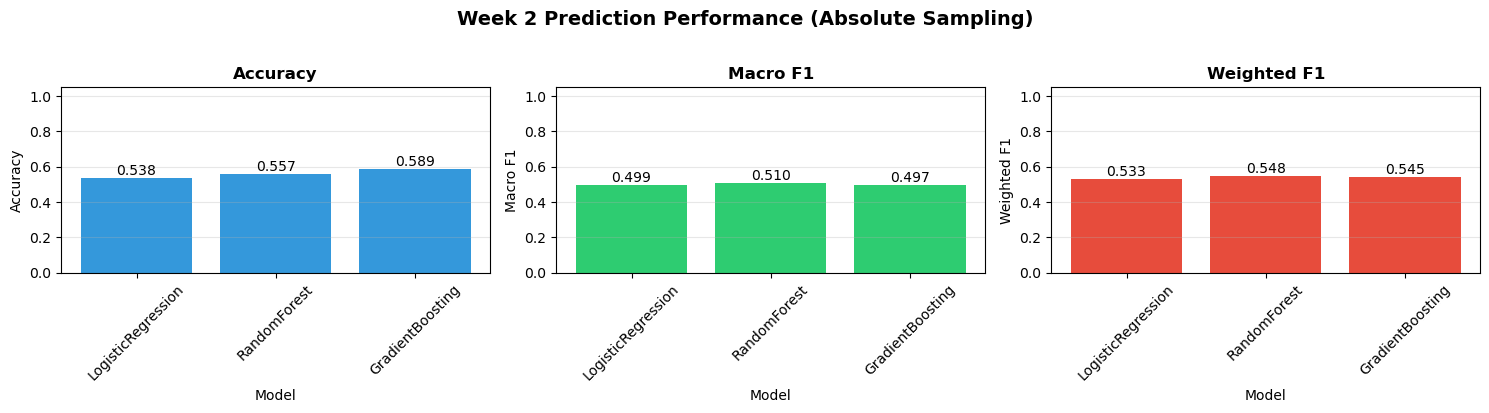


🏆 Best model (by Macro F1): RandomForest = 0.5098

             Model  Accuracy  Macro F1  Weighted F1
LogisticRegression  0.538475  0.499456     0.533442
      RandomForest  0.557425  0.509800     0.547613
  GradientBoosting  0.588925  0.497279     0.544691


In [7]:
# Performance comparison visualization
perf_df = plot_performance_comparison(results_week2, title="Week 2 Prediction Performance (Absolute Sampling)")
print("\n" + perf_df.to_string(index=False))

### Confusion Matrices

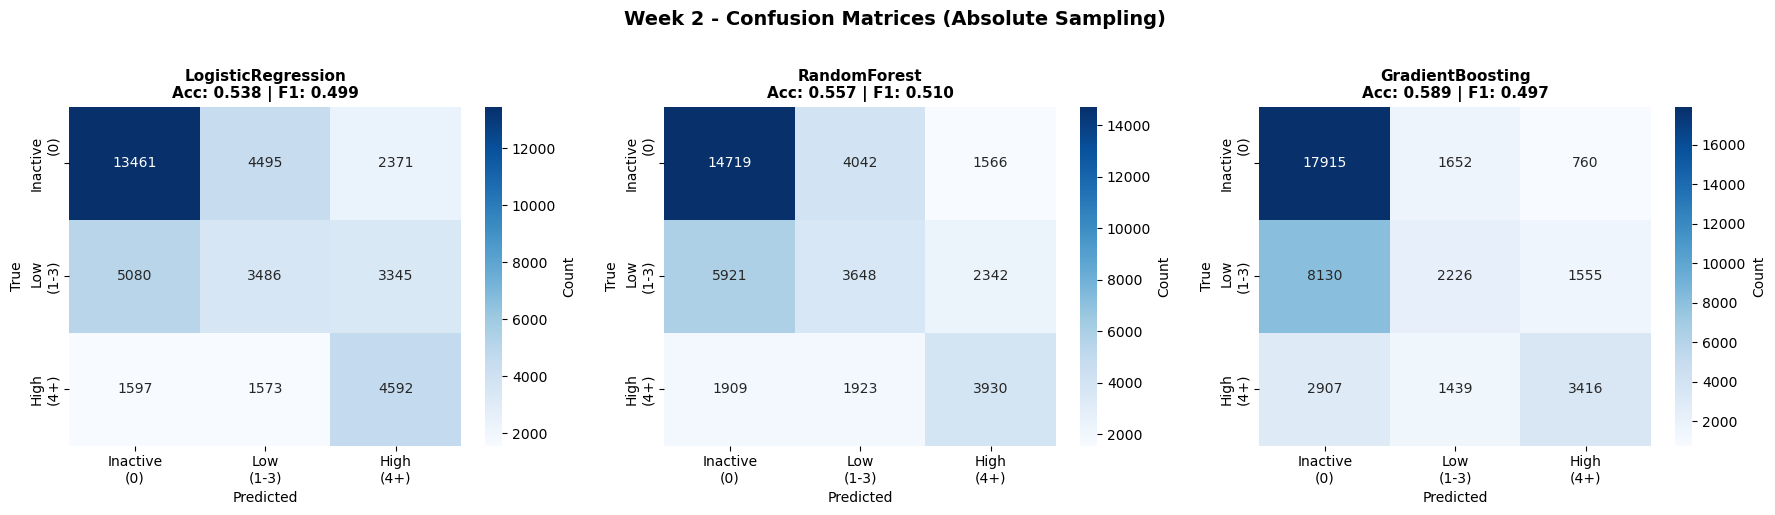

In [8]:
# Confusion matrices visualization
plot_confusion_matrices(results_week2, title="Week 2 - Confusion Matrices (Absolute Sampling)")

✓ Random Forest confusion matrix saved to: ../../data/ale_simplicistic_model/absolute/rf_confusion_matrix_week2.png
  Image size: 300 DPI, high quality for presentations


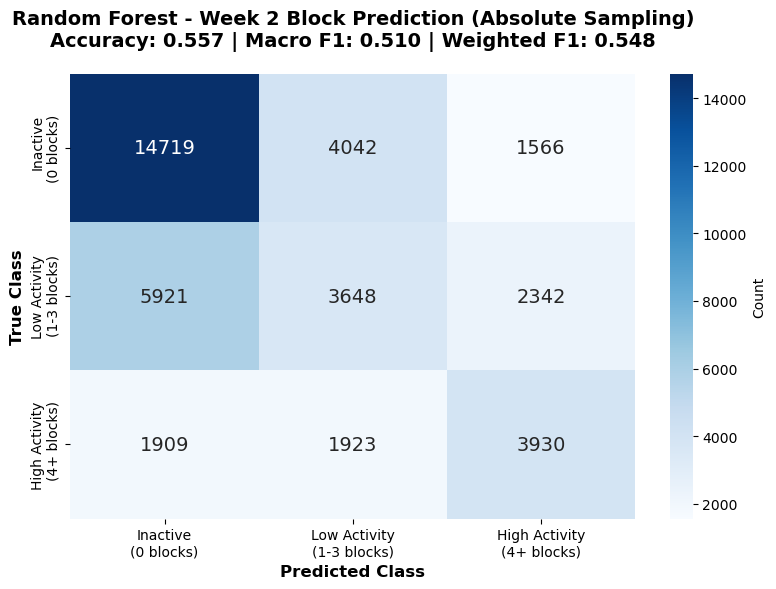

In [9]:
# Save Random Forest confusion matrix for presentation
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure for Random Forest only
fig, ax = plt.subplots(figsize=(8, 6))

# Get confusion matrix
cm = results_week2['RandomForest']['confusion_matrix']
class_labels = ['Inactive\n(0 blocks)', 'Low Activity\n(1-3 blocks)', 'High Activity\n(4+ blocks)']

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})

# Get metrics
acc = results_week2['RandomForest']['accuracy']
f1_macro = results_week2['RandomForest']['f1_macro']
f1_weighted = results_week2['RandomForest']['f1_weighted']

# Title with metrics
ax.set_title(f'Random Forest - Week 2 Block Prediction (Absolute Sampling)\n' + 
             f'Accuracy: {acc:.3f} | Macro F1: {f1_macro:.3f} | Weighted F1: {f1_weighted:.3f}',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save to file
output_path = '../../data/ale_simplicistic_model/absolute/rf_confusion_matrix_week2.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Random Forest confusion matrix saved to: {output_path}")
print(f"  Image size: 300 DPI, high quality for presentations")

plt.show()

### Save Trained Models

In [10]:
# Save all trained models
import joblib

metadata_path = save_models(
    results_week2, 
    scaler=data['scaler'], 
    feature_cols=list(X.columns), 
    week_label="Week 2 (Absolute)",
    model_dir="../../data/ale_simplicistic_model/absolute/model_ready"
)

# Also save results for import into multi-week comparison notebook
results_path = "../../data/ale_simplicistic_model/absolute/model_ready/results_week2.pkl"
joblib.dump(results_week2, results_path)
print(f"\n✓ Week 2 results saved for comparison: {results_path}")


SAVING MODELS - Week 2 (Absolute)
✓ LogisticRegression saved: ../../data/ale_simplicistic_model/absolute/model_ready/logisticregression_week2(absolute)_20260201_183140.pkl
✓ RandomForest saved: ../../data/ale_simplicistic_model/absolute/model_ready/randomforest_week2(absolute)_20260201_183140.pkl
✓ GradientBoosting saved: ../../data/ale_simplicistic_model/absolute/model_ready/gradientboosting_week2(absolute)_20260201_183140.pkl
✓ Scaler saved: ../../data/ale_simplicistic_model/absolute/model_ready/scaler_week2(absolute)_20260201_183140.pkl
✓ Metadata saved: ../../data/ale_simplicistic_model/absolute/model_ready/metadata_week2(absolute)_20260201_183140.pkl

✓ Week 2 results saved for comparison: ../../data/ale_simplicistic_model/absolute/model_ready/results_week2.pkl
✓ GradientBoosting saved: ../../data/ale_simplicistic_model/absolute/model_ready/gradientboosting_week2(absolute)_20260201_183140.pkl
✓ Scaler saved: ../../data/ale_simplicistic_model/absolute/model_ready/scaler_week2(abso